In [1]:
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
#from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

from altaipony.ffd import FFD, generate_random_power_law_distribution
import matplotlib.pyplot as plt

for att in ['axes.labelsize', 'axes.titlesize', 'legend.fontsize',
            'legend.fontsize', 'xtick.labelsize', 'ytick.labelsize']:
    plt.rcParams[att] = 16


/home/paola/anaconda3/lib/python3.9/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /home/paola/.lightkurve/cache. Please move all the files in the legacy directory /home/paola/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


In [2]:
#### Parametros do setor 1 ######
data=np.loadtxt('parametros_setor1.txt')
dur=data[:,0]
sub=data[:,1]
des=data[:,2]
ampl=data[:,3]
ener = data[:,4]
#### Parametros do setor 27 2Min ######
data2=np.loadtxt('par_setor27_2Min.txt')
dur2=data2[:,0]
sub2=data2[:,1]
des2=data2[:,2]
ampl2=data2[:,3]
ener2 = data2[:,4]
#### Parametros do setor 27 20s ######
data3=np.loadtxt('par_setor27_20s.txt')
dur3=data3[:,0]
sub3=data3[:,1]
des3=data3[:,2]
ampl3=data3[:,3]
ener3= data3[:,4]
print(ener3)

[2.45916e+32 2.11667e+32 3.65317e+32 6.27081e+33 8.07592e+32 1.32363e+32
 8.29914e+32 7.53556e+31 4.68724e+31 8.73481e+31 4.42280e+32 3.01060e+33
 4.00186e+31 7.17323e+31 3.88171e+31 1.02342e+32 1.22956e+33 8.71834e+32
 1.60268e+32 4.41632e+32 1.59266e+32 5.99602e+32 6.72049e+31 4.58150e+32
 1.06829e+33 4.24721e+33 2.13187e+32 1.10374e+34 3.39906e+33 1.21516e+33
 2.70666e+32 9.50105e+31 2.03081e+33 1.56246e+34 1.37250e+32 3.42373e+33
 2.75021e+32 1.06233e+32 1.21275e+33 1.25799e+33 4.13262e+31 7.40244e+31
 3.43904e+32]


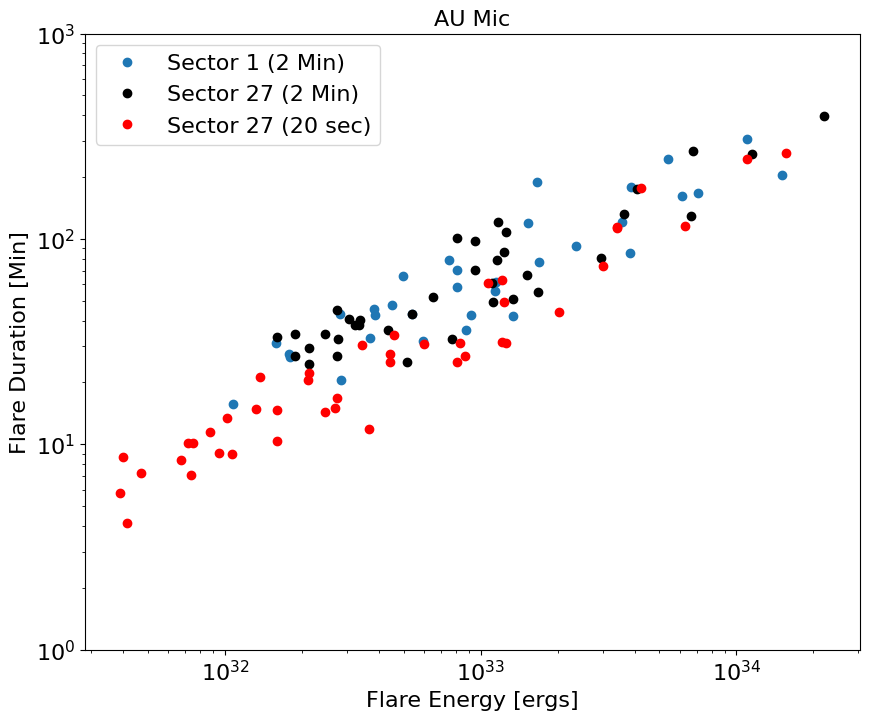

In [13]:
## Definindo eixo x para as energias
x_s1 = ener
x_s27 = ener2
x_s27_20s = ener3
# Definindo o eixo y para a duração 
y_s1 = dur
y_s27 = dur2
y_s27_20s = dur3
plt.figure(figsize=(10, 8))

plt.yscale('log')
plt.xscale('log')
plt.plot(x_s1, y_s1, 'o', label = 'Sector 1 (2 Min)')
plt.plot(x_s27, y_s27, 'ko', label = 'Sector 27 (2 Min)')
plt.plot(x_s27_20s, y_s27_20s, 'ro', label = 'Sector 27 (20 sec)')
plt.ylim(1e0,1e3)
#plt.xlim(1e28,1e37)
plt.title('AU Mic')
plt.xlabel("Flare Energy [ergs]")
plt.ylabel("Flare Duration [Min]")
plt.legend()
plt.show()

In [23]:

x = []
ene = []
tamanho = [np.log10]
count=0
for j in range(11):
    count=0
    ene.append(32+j*0.2)
    for i in range(len(ener)):
        if (32.2+(j*0.2))>np.log10(ener[i]) and np.log10(ener[i])>(32+(j*0.2)):
            count+=1
    x.append(count)

x2 = []
ene2 = []
count2=0
for j in range(11):
    count2 = 0
    ene2.append(32.2+j*0.2)
    for i in range(len(ener2)):
        if (32.4+(j*0.2))>np.log10(ener2[i]) and np.log10(ener2[i])>(32.2+(j*0.2)):
            count2+=1
    x2.append(count2)

x3 = []
ene3 = []
count3=0
for j in range(14):
    count3 = 0
    ene3.append(31.4+j*0.2)
    for i in range(len(ener3)):
        if (31.6+(j*0.2))>np.log10(ener3[i]) and np.log10(ener3[i])>(31.4+(j*0.2)):
            count3+=1
    x3.append(count3)


/tmp/ipykernel_14724/696576182.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.scatter((ene3),np.log10(x_y3),label = 'Sector 27(20 sec)',c='black', marker = '^')


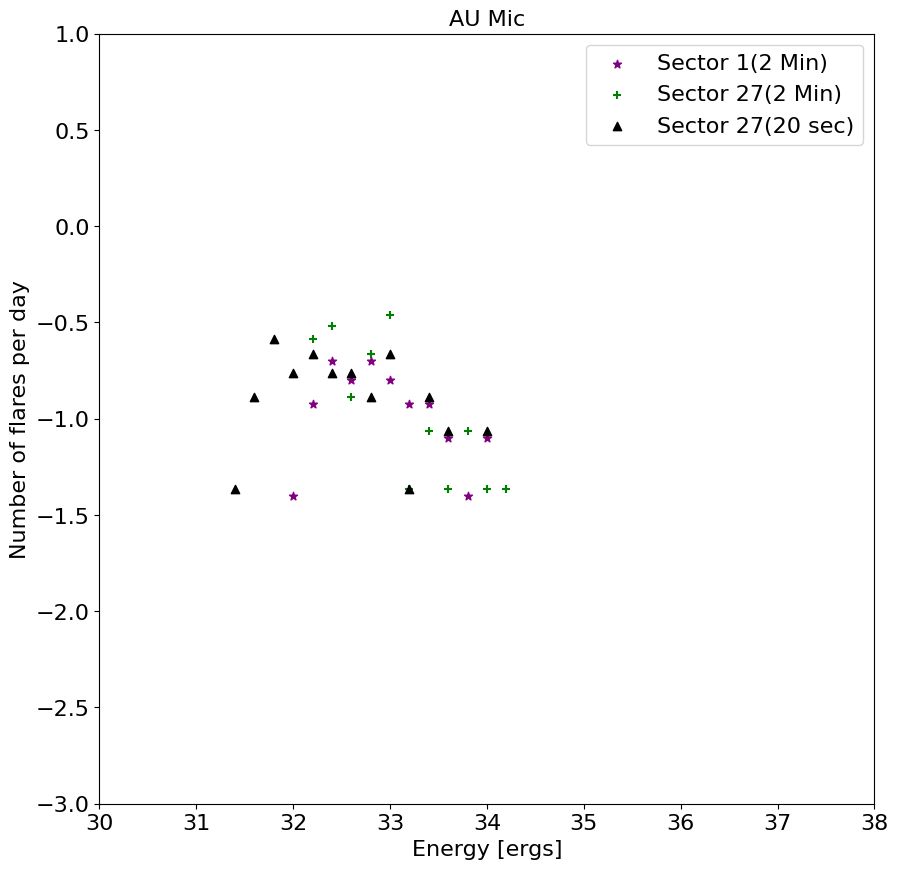

In [29]:
x_y = np.array(x)/25.09
x_y2 = np.array(x2)/23.09
x_y3 = np.array(x3)/23.09
plt.figure(figsize=(10, 10))

plt.scatter((ene),np.log10(x_y), label = 'Sector 1(2 Min)' , c='purple', marker = '*')
plt.scatter((ene2),np.log10(x_y2), label = 'Sector 27(2 Min)', c='green', marker = '+')
plt.scatter((ene3),np.log10(x_y3),label = 'Sector 27(20 sec)',c='black', marker = '^')
#plt.plot((ene),x_y, label = 'Sector 1(2 Min)' )
#plt.plot((ene2),x_y2, label = 'Sector 27(2 Min)')
#plt.plot((ene3),x_y3,label = 'Sector 27(20 sec)')
plt.legend()
#plt.ylim(-1.5,0)
#plt.xlim(31.5,34.5)
plt.ylim(-3.0,1)
plt.xlim(30,38)
plt.title('AU Mic')
plt.xlabel("Energy [ergs]")
plt.ylabel("Number of flares per day");
#plt.yscale('log')
plt.show()

In [183]:
from altaipony.ffd import FFD, generate_random_power_law_distribution

simple_ffd = FFD(f=ener,tot_obs_time=25.07)
simple_ffd2 = FFD(f=ener2,tot_obs_time =23.07)
simple_ffd3 = FFD(f=ener3,tot_obs_time=23)

In [175]:

# a, b, g, size = energy lower and upper limit, power law exponent +1, number of flares
#pwl = generate_random_power_law_distribution(1e31, 1e34, -1, size=33, seed = 80)
#pwl2 = generate_random_power_law_distribution(1e31, 1e34, -1, size=37, seed = 80)
#pwl3 = generate_random_power_law_distribution(1e31, 1e34, -1, size=43, seed = 80)
pwl = generate_random_power_law_distribution(1e32, 1e34, -1, size=33, seed = 80)
pwl2 = generate_random_power_law_distribution(1e32, 2e34, -1, size=37, seed = 80)
pwl3 = generate_random_power_law_distribution(1e31, 1e34, -1, size=43, seed = 80)

#pwl= energy
# Create a FFD with the energies you detected. 
simple_ffd = FFD(f=pd.DataFrame({"ed_rec": pwl}))
simple_ffd2 = FFD(f=pd.DataFrame({"ed_rec": pwl2}))
simple_ffd3 = FFD(f=pd.DataFrame({"ed_rec": pwl3}))


No total observing time given. Set to 1. You are now working with number counts instead of frequency.
No total observing time given. Set to 1. You are now working with number counts instead of frequency.
No total observing time given. Set to 1. You are now working with number counts instead of frequency.


In [184]:
#simple_ffd
simple_ffd.tot_obs_time =25.07 #days
simple_ffd2.tot_obs_time =23.29 #days
simple_ffd3.tot_obs_time =23.29 #days

ed, freq, counts = simple_ffd.ed_and_freq()
ed2, freq2, counts2 = simple_ffd2.ed_and_freq()
ed3, freq3, counts3 = simple_ffd3.ed_and_freq()


TypeError: copy() got an unexpected keyword argument 'deep'

In [177]:
print(ener3)

[2.45916e+32 2.11667e+32 3.65317e+32 6.27081e+33 8.07592e+32 1.32363e+32
 8.29914e+32 7.53556e+31 4.68724e+31 8.73481e+31 4.42280e+32 3.01060e+33
 4.00186e+31 7.17323e+31 3.88171e+31 1.02342e+32 1.22956e+33 8.71834e+32
 1.60268e+32 4.41632e+32 1.59266e+32 5.99602e+32 6.72049e+31 4.58150e+32
 1.06829e+33 4.24721e+33 2.13187e+32 1.10374e+34 3.39906e+33 1.21516e+33
 2.70666e+32 9.50105e+31 2.03081e+33 1.56246e+34 1.37250e+32 3.42373e+33
 2.75021e+32 1.06233e+32 1.21275e+33 1.25799e+33 4.13262e+31 7.40244e+31
 3.43904e+32]


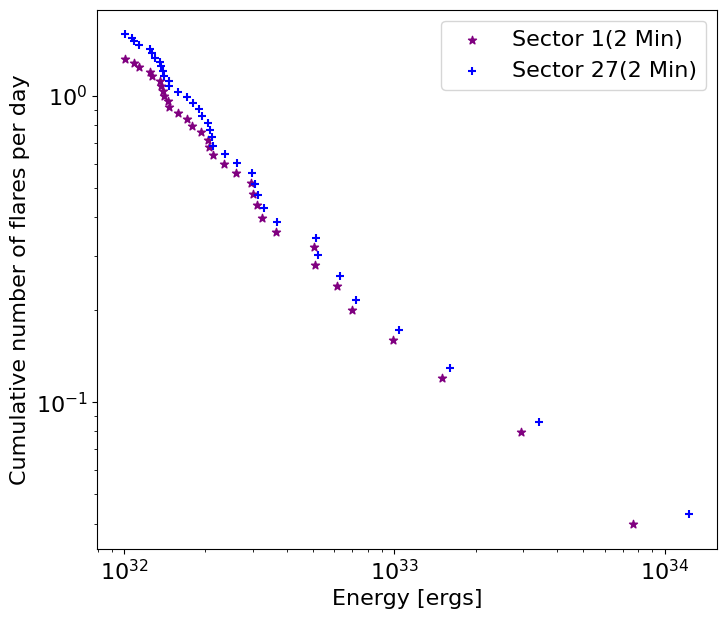

In [178]:
%matplotlib inline
plt.figure(figsize=(8, 7))
plt.scatter(ed, freq, c="purple", marker="*", label = 'Sector 1(2 Min)')
plt.scatter(ed2, freq2, c="blue", marker="+", label = 'Sector 27(2 Min)')
#plt.scatter(ed3, freq3, c="red", marker="x")

plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [ergs]")
plt.ylabel("Cumulative number of flares per day");

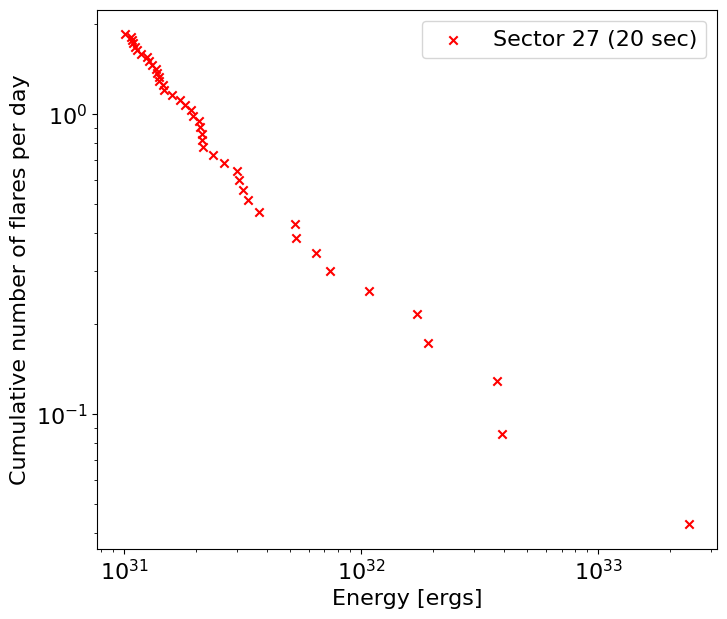

In [179]:
%matplotlib inline
plt.figure(figsize=(8, 7))
#plt.scatter(ed, freq, c="purple", marker="*", label = 'Sector 1(2 Min)')
#plt.scatter(ed2, freq2, c="blue", marker="+", label = 'Sector 27(2 Min)')
plt.scatter(ed3, freq3, c="red", marker="x", label = 'Sector 27 (20 sec)')
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [ergs]")
plt.ylabel("Cumulative number of flares per day");

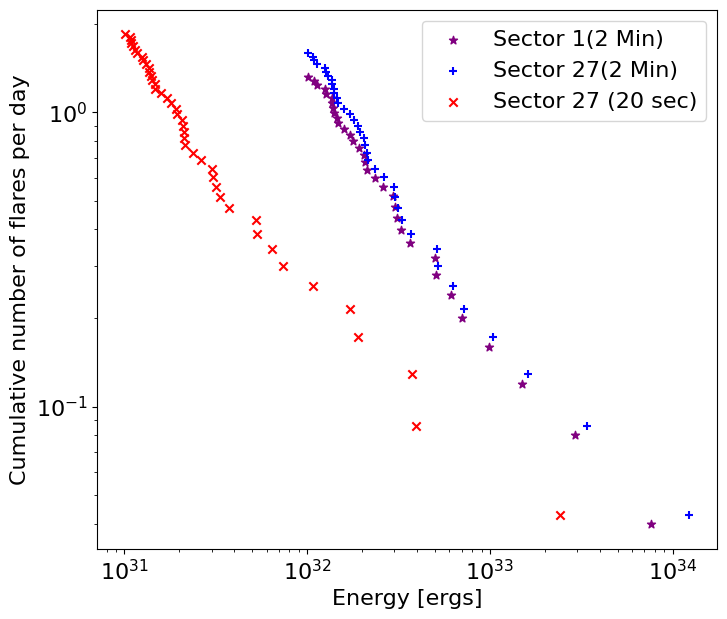

In [180]:
%matplotlib inline
plt.figure(figsize=(8, 7))
plt.scatter(ed, freq, c="purple", marker="*", label = 'Sector 1(2 Min)')
plt.scatter(ed2, freq2, c="blue", marker="+", label = 'Sector 27(2 Min)')
plt.scatter(ed3, freq3, c="red", marker="x", label = 'Sector 27 (20 sec)')
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [ergs]")
plt.ylabel("Cumulative number of flares per day");